In [40]:
import random
import json
import os, sys
from importlib import reload
from pathlib import Path
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")


In [41]:
# My modules

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools)

from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz


In [42]:
# Files
STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

VQA_RESP = WORK_DIR / "outputs/vqa_video_fps_gemma3:4b-it-qat_20250629_16:44:00.jsonl"

QA_SGG_OLD = WORK_DIR / "outputs/responses_on_small_val_gemma3:4b-it-qat_20250609_21:50:00.jsonl"
QA_SGG = WORK_DIR / "outputs/gu_on_sgg_notbatched_20250701_u3_gemma3:4b-it-qat_20250704_15:01:00.jsonl"
#QA_SGG = WORK_DIR / "outputs/gu_on_sgg_wout_noneofothersalt_20250628_00:26:00_gemma3:4b-it-qat_20250629_17:27:00.jsonl"
#QA_SGG = WORK_DIR / "outputs/gu_on_sgg2_wout_noneofother_alt_gemma3:4b-it-qat_20250t03_18:18:00.jsonl"
#QA_SGG = WORK_DIR / "outputs/gu_on_sgg2_gemma3:4b-it-qat_20250t03_18:18:00.jsonl"

SGG_GRAPHS = WORK_DIR / "outputs/sgg/sgg_1fps_notbatched_gemma3:4b-it-qat_202500701_14:50:00.jsonl"


RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]


DISPLAY_VIDEO = False


# Experiment
### Comparison between VQA and QA on generated frames - same sample rate from video


**Parameters:**
- model: Gemma3:4b-it-qat
- user_prompt: vqa/user_prompt_v2.txt
- temperature: 0.1
- sampling method: (default) top-p (p=0.9)

# Prompts

## VQA

In [43]:
with open(WORK_DIR / 'data/prompts/vqa/user_prompt_v2.txt', 'r') as f:
    pr = f.read()

print(pr)


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

In [44]:
with open(WORK_DIR / 'data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt', 'r') as f:
    pr = f.read()

print(pr)


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



## SGG

In [45]:
with open(WORK_DIR / "data/prompts/graph-gen/user_prompt_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by the person;
7.

In [46]:
with open(WORK_DIR / "data/prompts/graph-gen/format_instructions_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


Now organize the objects and relationships you identified before into a formal scene graph using this format:
object1 ---- relationship ---- object2

The list of relationship predicates should be introduced for each frame should be introduce by the frame ID or 
name and finally by the tag <scene_graph> and terminated by the tag </scene_graph>.

For example:
Frame 0:
<scene_graph>
man ---- sitting_on ---- chair
dog ---- lying_under ---- table
book ---- on_top_of ---- shelf
...
</scene_graph>

Frame 2:
<scene_graph>
woman ---- on_the_left_of ---- man
...
<scene_graph>
...


Please follow these guidelines:
1. Create an adequate number of relationship triplets (more if the image is complex)
2. Use specific and consistent object labels
3. Use concise but descriptive relationship terms (connect words with underscores)
4. Include all meaningful relationships between objects
5. Verify that all objects you identified in step 1 appear in at least one relationship
6. You can condense multiple vis

### Graph understanding from the SGG

Launch script:

```bash
  python -m star_code.src.main \
  --task graph-understanding \
  --model gemma3:4b-it-qat \
  --model-options star_code/ollama_model_options.json \
  --prompt-type mcq_zs_cot \
  --sys-prompt star_code/data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt \
  --user-prompt star_code/data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v4.txt \
  --mode chat \
  --reply-file star_code/data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt \
  --dataset-type star \
  --input-file star_code/data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json \
  --stsg-file star_code/outputs/gen_stsg_videofps_gemma3:4b-it-qat_20250628_00:26:00.jsonl \
  --output-file star_code/outputs/gr_understaing_on_genstg_20250628_00:26:00_val_gemma3:4b-it-qat_20250701_11:27:00.jsonl 
```

In [47]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


You need to respond to reasoning questions by making logical inference on sequence of Scene-Graphs extracted from frames belonging to a video, called a Spatio-Temporal Scene Graph.

IMPORTANT CLARIFICATIONS:
- You will receive a question and Spatio-Temporal Scene-Graph
- Each Scene-Graph is a static symbolic representation of the scene unfolding in the frame
- The Scene-Graphs are ordered chronologically
- The Scene-Graph is represented as a set of tuple in the format: subject - relationship - object
- The Spatio-Temporal Scene-Graph is a cornologically sorted list of Scene-Graphs

INSTRUCTIONS:
- Read the entire Spatio-Temporal Scene-Graphs in chronological order and pay attention at the order of how events unfold.
- Read the question and reason about the answer step by step.
- In your answer include key events or relationships that help you in determing the correct answer.
- Be careful to reproduce the chosen alternative as it is presented.


In [48]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v3.txt") as f:
    pr = f.read()
    
print(pr)
    


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
{stsg}
</STSG>

Given the following question:
<Q>
{question}
<Q>

And the following alternatives:
<Alternatives>
A. {c1}
B. {c2}
C. {c3}
D. {c4}
</Alternatives>

Provide an answer to the above question reasoning step by step on the Spatio-Temporal Scene-Graph (STSG) and choosing one of the alternatives. 

In answering the question please be sure to operate according to the following guidlines:
1. Question Interpretation: Clearly state what the question is asking
2. STSG Analysis: Carefully examine the spatial and temporal relationships in the scene graph
3. Alternative Evaluation: For each option (A, B, C, D), explain whether it matches the STSG evidence
4. Reasoning: Provide clear logical step by step reasoning leading to your conclusion
5. Conclusion: Declare the logical conclusion to your reasoning in the above step
6. Consistency Check: B

In [49]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



# Loading GT

Let's load the ground truth from the `STAR_QA_question_and_stsg_val.json` file where we extracted QA and spatio-temporal scene graphs

In [50]:
with open(WORK_DIR / 'data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB


## Loading Generated Grpahs

In [51]:
sgg_df = pd.read_json(SGG_GRAPHS, lines=True)
sgg_df


,video_id,start,end,chat_history,stsg
0,ATV2F,0.0,4.000,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 1:\n\nwoman ---- sitting_on ---- chair...
1,9J166,9.9,17.500,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\n\nyoung_man ---- standing_in_fro...
2,ANA5N,4.3,10.300,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\nwoman ---- holding ---- brown_le...
3,Z6HEA,0.0,10.875,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\nwoman ---- standing_in_front_of ...
4,FRLW2,3.4,27.275,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\nperson ---- standing_in_front_of...
...,...,...,...,...,...
914,HL5OP,19.0,27.900,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\nFrame 1:\n\n\nwooden_chair_1 ---...
915,F9YMU,11.9,16.500,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\n\nperson ---- sitting_at ---- ta...
916,1333C,8.0,13.100,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\nFrame 1:\n\nwoman ---- holding -...
917,KU656,0.0,6.800,"[{'role': 'user', 'content': 'Look carefully a...",\nFrame 0:\n\n\nwoman ---- lying_on ---- bed\n...


In [52]:
print(sgg_df.iloc[495]['chat_history'][-1]['content'])


<scene_graph>
door ---- attached_to ---- wall
door ---- has_handle ---- door_handle
door_handle ---- attached_to ---- door
door ---- has_knob ---- door_knob
door_knob ---- attached_to ---- door
door_handle ---- on_top_of ---- door_knob
wall ---- supports ---- door
door ---- casts_shadow_on ---- wall
light_fixture ---- above ---- door
light_fixture ---- illuminates ---- door
door ---- reflects_in ---- light_fixture
wall ---- reflects_light_from ---- light_fixture
door ---- is_within ---- wall
light_fixture ---- is_mounted_on ---- wall
door ---- is_part_of ---- room
wall ---- is_part_of ---- room
</scene_graph>


# Loading predicted answers evaluation

In [53]:
reload(rp)


<module 'src.response_processing' from '/home/lusha/star_code/src/response_processing.py'>

In [54]:
pred_vqa_df = rp.gemma3_ans_extract(VQA_RESP)
pred_sgg_df = rp.gemma3_ans_extract(QA_SGG)


Total answers: 1039
Answers following JSON template: 1039
Percentage following JSON template: 100.00%
Answer following the template: 1039
100.00% of the total

Only 0 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


Total answers: 1046
Answers following JSON template: 1046
Percentage following JSON template: 100.00%
Answer following the template: 817
78.11% of the total

Only 229 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


In [55]:
pred_vqa_df = pred_vqa_df.loc[pred_vqa_df['contains_answer']]
pred_sgg_df = pred_sgg_df.loc[pred_sgg_df['contains_answer']]


In [56]:
pred_vqa_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df1 = gt_df.join(
    pred_vqa_df.loc[pred_vqa_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df1, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          298        48.32%  
Sequence             288        46.88%  
Prediction           235        37.45%  
Feasibility          218        39.45%  

Average             1039        43.60%  


In [57]:
rp.print_ans_perc(eval_df1, gt_df)


Question type       Total      Answered 

Interaction          298       100.00%  
Sequence             291        98.97%  
Prediction           239        98.33%  
Feasibility          220        99.09%  
Overall             1048        99.14%  


In [58]:
pred_sgg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_sgg_df.loc[pred_sgg_df['contains_answer']], 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          207        43.48%  
Sequence             217        41.47%  
Prediction           219        41.10%  
Feasibility          174        36.21%  

Average              817        40.76%  


In [39]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        69.46%  
Sequence             291        74.57%  
Prediction           239        91.63%  
Feasibility          220        79.09%  
Overall             1048        77.96%  


In [ ]:
print(sgg_df.iloc[0]['chat_history'][0]['content'])


Look carefully at this image and identify all objects and relationships present.

First, list all distinct objects you can detect in the image. Be thorough and specific with your object labels (e.g., "young woman" rather than just "person", "wooden chair" rather than just "chair").

Then, describe the key relationships between these objects in free-form text. Consider:
- Spatial relationships (above, below, behind, inside, etc.)
- Action-based relationships (holding, looking at, sitting on, etc.)
- Physical connections (attached to, part of, touching, etc.)
- Relative positions (next to, between, surrounding, etc.)

Think step by step


### Why is the accuracy with the generated SG as base so low?

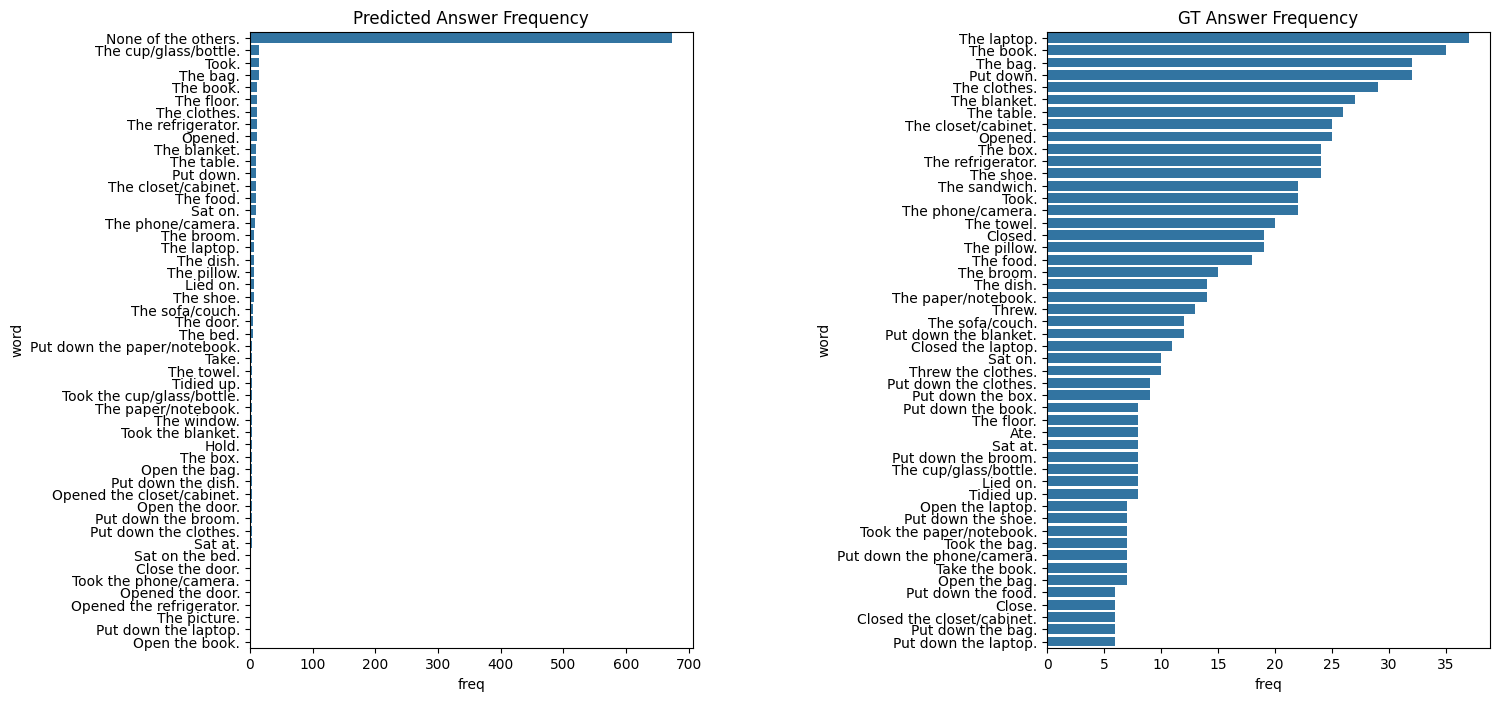

In [21]:
freq_pred = pred_sgg_df['pred_text'].value_counts().reset_index()
freq_pred.columns = ["word", "freq"]

freq_gt = gt_df['text'].value_counts().reset_index()
freq_gt.columns = ["word", "freq"]


fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={'wspace': 0.8}   # adjust wspace to taste
)

sns.barplot(
    data=freq_pred.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[0]
)
axes[0].set_title("Predicted Answer Frequency")

sns.barplot(
    data=freq_gt.sort_values('freq', ascending=False)[:50],
    x="freq", y="word",
    ax=axes[1]
)

axes[1].set_title("GT Answer Frequency")
plt.show()


That's way. For > half of the Q the model answers with None of the others.

<Axes: xlabel='freq', ylabel='word'>

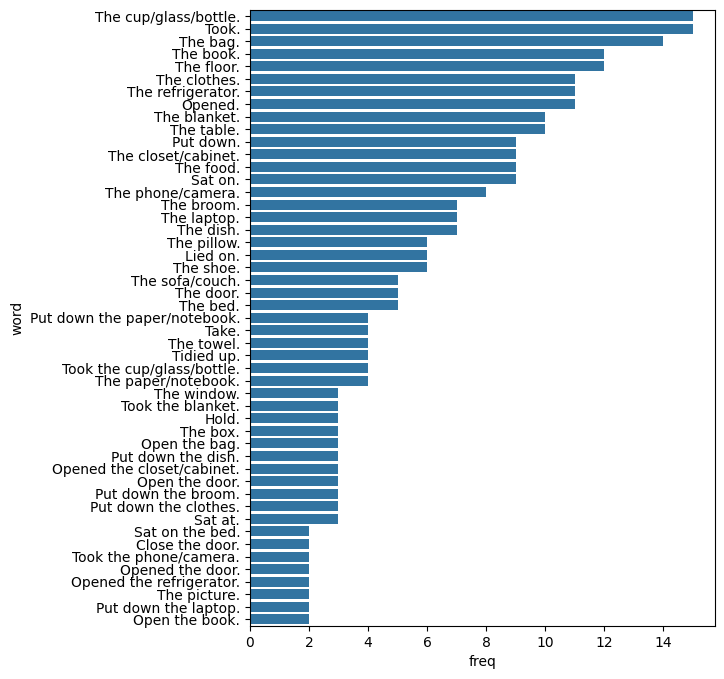

In [22]:
plt.figure(figsize=(6, 8))
sns.barplot(data=freq_pred.iloc[1:50], x='freq', y='word')


### Reasoning token length

In [23]:
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    auth_token=hugg_auth_token
)


Reasoning length:

In [24]:
reasoning_token_len_sgg = pred_sgg_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[1]['content'])))
reasoning_token_len_sgg.describe()


count    1035.000000
mean      524.463768
std       129.636553
min       283.000000
25%       466.000000
50%       510.000000
75%       560.000000
max      2048.000000
Name: chat_history, dtype: float64

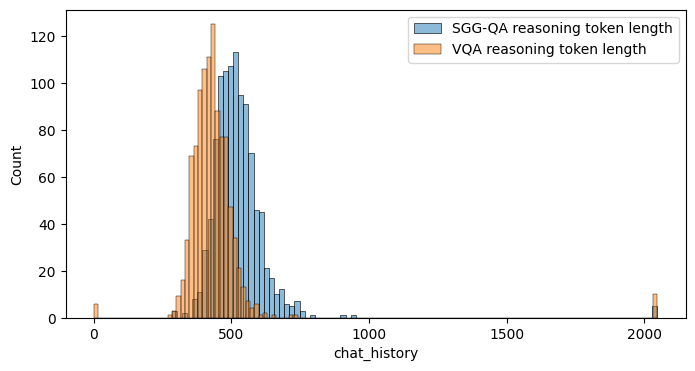

In [25]:
reasoning_token_len_vqa = pred_vqa_df['chat_history'].apply(lambda x: len(gemma3_tokenizer.tokenize(x[1]['content'])))

plt.figure(figsize=(8,4))

sns.histplot(reasoning_token_len_sgg, alpha=.5, label="SGG-QA reasoning token length")
sns.histplot(reasoning_token_len_vqa, alpha=.5, label="VQA reasoning token length")
plt.legend()


The reasoning token is not too different form other experiments.

### Looking at some correct answers

In [26]:
rp.print_acc(eval_df2.loc[prev_analyzed], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          15         33.33%  
Sequence              0          nan%   
Prediction            0          nan%   
Feasibility           0          nan%   

Average              15         33.33%  


/home/lusha/star_code/src/response_processing.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]
/home/lusha/star_code/src/response_processing.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]
/home/lusha/star_code/src/response_processing.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]


In 1/3 (= 5 samples) of the manually inspected samples the new fps based model is able to answer correctly. Let's see why...

In [27]:
correct_idx = (eval_df2.loc[prev_analyzed, 'text'] == eval_df2.loc[prev_analyzed, 'pred_text'])
correct_idx =  correct_idx[correct_idx].index
correct_idx


Index(['Interaction_T1_8913', 'Interaction_T2_3423', 'Interaction_T1_2226',
       'Interaction_T1_8274', 'Interaction_T1_4221'],
      dtype='string', name='id')

#### 0

In [28]:
idx = correct_idx[0]


In [29]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [pred_sgg_df.rename(columns={'pred_text': 'answer'})])



┌─ Sample: Interaction_T1_8913 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The paper/notebook.
│    1. The laptop.
│    2. The bag.
│    3. The cup/glass/bottle.
│
│ Ground Truth:
│    The paper/notebook.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The paper/notebook. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the scene graph and answer the question step-by-step.
│        
│        **1. Question Interpretation:**
│        
│        The question asks: "Which object was taken by the person?" This means we need to identify the object that the person (the ‘man’) is holding or interacting with in a way that suggests it’s being moved or carried.
│        
│        **2. STSG Analysis:**
│        
│        The scene graph describes the following relationships:
│        
│        *   **Frame 0:** man ---- sitting_on ---- chair, laptop ---- on ---- desk, paper ---- held_b

In [30]:
if DISPLAY_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [31]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a scene graph representing the observed events, organized by frame and utilizing the specified format:

<scene_graph>

**Frame 0:**
<scene_graph>
man ---- sitting_on ---- chair
laptop ---- on ---- desk
paper ---- held_by ---- man
sheets ---- on ---- table
</scene_graph>

**Frame 1:**
<scene_graph>
man ---- leaning_towards ---- desk
laptop ---- on ---- desk
paper ---- held_by ---- man
sheets ---- on ---- table
</scene_graph>

**Frame 2:**
<scene_graph>
man ---- leaning_towards ---- desk
laptop ---- on ---- desk
paper ---- held_by ---- man
sheets ---- on ---- table
</scene_graph>

**Frame 3:**
<scene_graph>
man ---- leaning_towards ---- desk
laptop ---- on ---- desk
paper ---- held_by ---- man
sheets ---- on ---- table
</scene_graph>

**Frame 4:**
<scene_graph>
man ---- sitting_on ---- chair
laptop ---- on ---- desk
paper ---- held_by --

#### 1

In [32]:
idx = correct_idx[1]


In [33]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [pred_sgg_df.rename(columns={'pred_text': 'answer'})])



┌─ Sample: Interaction_T2_3423 ─────────────────────────────────────────────────────────────
│
│ Question:
│    What did the person do with the bed?
│ Alternatives:
│    0. Sat on.
│    1. Closed.
│    2. Lied on.
│    3. Washed.
│
│ Ground Truth:
│    Lied on.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  Lied on. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the scene graph and answer the question.
│        
│        **1. Question Interpretation:**
│        
│        The question asks: "What did the person do with the bed?"  We need to identify the action associated with the bed throughout the video frames.
│        
│        **2. STSG Analysis:**
│        
│        The scene graph describes the state of the scene at each frame.  Crucially, it repeatedly states: “child ---- lying_on ---- bed”. This indicates the child is lying *on* the bed.  The other relationships (bed located in room, room painted reddish-brown, bed located near window, window has curtain, bed

In [34]:
if DISPLAY_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [35]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a scene graph representing the video, incorporating the details from the previous analysis:

<scene_graph>

**Frame 0:**
child ---- lying_on ---- bed
bed ---- located_in ---- room
room ---- painted_in ---- reddish-brown
bed ---- located_near ---- window
window ---- has ---- curtain
curtain ---- is ---- white
bed ---- has ---- pillow
pillow ---- is ---- white

**Frame 1:**
child ---- lying_on ---- bed
bed ---- located_in ---- room
room ---- painted_in ---- reddish-brown
bed ---- located_near ---- window
window ---- has ---- curtain
curtain ---- is ---- white
bed ---- has ---- pillow
pillow ---- is ---- white

**Frame 2:**
child ---- lying_on ---- bed
bed ---- located_in ---- room
room ---- painted_in ---- reddish-brown
bed ---- located_near ---- window
window ---- has ---- curtain
curtain ---- is ---- white
bed ---- has ---- pillow
pill

#### 2

In [36]:
idx = correct_idx[2]


In [37]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [pred_sgg_df.rename(columns={'pred_text': 'answer'})])



┌─ Sample: Interaction_T1_2226 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The shoe.
│    1. The blanket.
│    2. The box.
│    3. The laptop.
│
│ Ground Truth:
│    The shoe.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The shoe. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the scene graph and answer the question.
│        
│        **1. Question Interpretation:**
│        
│        The question asks: "Which object was taken by the person?" This means we need to identify the object that the person (the man) is actively moving or holding in a way that suggests it's being carried or brought to him.
│        
│        **2. STSG Analysis:**
│        
│        Let's examine the relationships in the scene graph frame by frame:
│        
│        *   **Frame 0:** The man is reaching *for* a white bag. This indicates he’s acquiring the bag.
│        *   **Frame 1:** The m

The answer is correct but only because it is hallucinated.

In [38]:
if DISPLAY_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [39]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a scene graph representing the observed actions and relationships, organized by frame and utilizing the specified format:

<scene_graph>

**Frame 0:**
man ---- reaching_for ---- white_bag
white_bag ---- located_on ---- table
table ---- located_in ---- indoor_space
indoor_space ---- contains ---- large_screens

**Frame 1:**
man ---- adjusting ---- white_bag
white_bag ---- tilted_towards ---- man
man ---- bending_over ---- table

**Frame 2:**
man ---- pulling_up ---- white_bag
white_bag ---- held_by ---- man
man ---- lifting_up ---- white_bag

**Frame 3:**
man ---- holding ---- white_bag
white_bag ---- presented_to ---- man
man ---- examining ---- white_bag

**Frame 4:**
man ---- holding_up ---- white_bag
white_bag ---- contained_within ---- man’s_hands
</scene_graph>
</STSG>

Given the following question:
<Q>
Which object was taken by t

#### 4

In [40]:
idx = correct_idx[3]


In [41]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [pred_sgg_df.rename(columns={'pred_text': 'answer'})])



┌─ Sample: Interaction_T1_8274 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The towel.
│    1. The dish.
│    2. The sandwich.
│    3. The phone/camera.
│
│ Ground Truth:
│    The dish.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The dish. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the scene graph and answer the question.
│        
│        **1. Question Interpretation:**
│        
│        The question asks: "Which object was taken by the person?" This means we need to identify the object that the person (the ‘man’) is actively moving or interacting with in a way that suggests it’s being acquired or carried.
│        
│        **2. STSG Analysis:**
│        
│        The scene graph describes the man’s actions and relationships with various objects. Let's break down the key events:
│        
│        *   **Frames 0-2:** The man is *holding* plates.
│        *   

In [42]:
if DISPLAY_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [43]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a scene graph representing the events and relationships observed in the video sequence:

<scene_graph>

**Frame 0:**
man ---- standing_at ---- table
table ---- has ---- plates
table ---- has ---- cutlery
vase ---- on ---- table
vase ---- has ---- flowers
man ---- holding ---- plates

**Frame 1:**
man ---- walking_towards ---- table
man ---- holding ---- plates

**Frame 2:**
man ---- picking_up ---- plates
man ---- carrying ---- plates

**Frame 3:**
man ---- walking_towards ---- table
man ---- holding ---- plates

**Frame 4:**
man ---- walking_towards ---- table
man ---- holding ---- plates

**Frame 5:**
man ---- walking_towards ---- table
man ---- holding ---- plates

**Frame 6:**
man ---- walking_towards ---- table
man ---- holding ---- plates

**Frame 7:**
man ---- walking_towards ---- table
man ---- holding ---- plates

**Frame 8:**

#### 5

In [44]:
idx = correct_idx[4]


In [45]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [pred_sgg_df.rename(columns={'pred_text': 'answer'})])



┌─ Sample: Interaction_T1_4221 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The blanket.
│    1. The book.
│    2. The shoe.
│    3. The clothes.
│
│ Ground Truth:
│    The shoe.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The shoe. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the scene graph and answer the question.
│        
│        1. **Question Interpretation:** The question asks: "Which object was taken by the person?" This implies we need to identify an object that the person is holding or interacting with in a way that suggests it’s being moved or carried.
│        
│        2. **STSG Analysis:** The scene graph consistently shows the man holding sneakers. The relationships indicate he’s *holding* the sneakers.  There’s no mention of any other object being taken. The scene graph focuses on the man, the sneakers, the laptop, and the table.
│        
│       

In [46]:
if DISPLAY_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [47]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a scene graph representing the objects and relationships observed in the video sequence, organized by frame and using the specified format:

Frame 0:
<scene_graph>
man ---- kneeling_next_to ---- table
table ---- containing ---- laptop
laptop ---- displaying ---- screen
screen ---- showing ---- text
</scene_graph>

Frame 1:
<scene_graph>
man ---- sitting_on ---- chair
chair ---- positioned_next_to ---- table
table ---- containing ---- laptop
laptop ---- displaying ---- screen
screen ---- showing ---- text
man ---- holding ---- sneakers
sneakers ---- on_floor
</scene_graph>

Frame 2:
<scene_graph>
man ---- sitting_on ---- chair
chair ---- positioned_next_to ---- table
table ---- containing ---- laptop
laptop ---- displaying ---- screen
screen ---- showing ---- text
man ---- touching ---- sneakers
sneakers ---- on_floor
</scene_graph>

Fr

In [48]:
video = sgg_df[(sgg_df[['video_id', 'start', 'end']] == gt_df.loc[idx, ['video_id', 'start', 'end']]).apply(all, axis=1)]
video


,video_id,start,end,chat_history,stsg
495,C8WLX,25.2,35.0,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph representing the objects ...


In [49]:
print(video.iloc[0]['chat_history'][0]['content'])


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

### Looking at wrong answers

In [50]:
pred_sgg_df


,chat_history,json_mask,contains_answer,pred_text
id,,,,
Feasibility_T5_102,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Feasibility_T2_860,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Feasibility_T2_556,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Prediction_T1_2539,"[{'role': 'user', 'content': 'Please carefully...",True,True,None of the others.
Prediction_T4_1253,"[{'role': 'user', 'content': 'Please carefully...",True,True,The pillow.
...,...,...,...,...
Interaction_T1_8913,"[{'role': 'user', 'content': 'Please carefully...",True,True,The paper/notebook.
Interaction_T1_8967,"[{'role': 'user', 'content': 'Please carefully...",True,True,The black_object.
Interaction_T2_1847,"[{'role': 'user', 'content': 'Please carefully...",True,True,Took.


In [51]:
none_mask = pred_sgg_df['pred_text'].str.startswith("None")


In [52]:
idx = none_mask.index[2]
idx


'Feasibility_T2_556'

In [53]:
qa_viz.compact_print_qa(none_mask.index[0], gt_df.rename(columns={'text': 'answer'}), [pred_sgg_df.rename(columns={'pred_text': 'answer'})])



┌─ Sample: Feasibility_T5_102 ──────────────────────────────────────────────────────────────
│
│ Question:
│    Which object is the person able to throw after walking through the doorway?
│ Alternatives:
│    0. The bag.
│    1. The book.
│    2. The blanket.
│    3. The clothes.
│
│ Ground Truth:
│    The clothes.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  None of the others. [WRONG]
│    Reasoning:
│        Okay, let's analyze the scene graph and answer the question.
│        
│        **1. Question Interpretation:**
│        
│        The question asks which object the person could potentially throw after walking through a doorway (implied, as the scene graph doesn't explicitly state a doorway). It’s essentially asking which object is in a position to be thrown.
│        
│        **2. STSG Analysis:**
│        
│        The scene graph describes a single person, a phone, a closet, clothes, and a red bag. The relationships are:
│        
│        *   The person is ho

In [54]:
print(pred_sgg_df.loc[idx, 'chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
Here’s a scene graph representing the video sequence, organized as requested:

<scene_graph>

Frame 0:
woman ---- holding ---- cloth
cloth ---- on ---- mirror
mirror ---- in ---- bathroom

Frame 1:
woman ---- holding ---- cloth
cloth ---- in ---- hand
woman ---- looking_at ---- cloth

Frame 2:
woman ---- holding ---- cloth
cloth ---- presented_to ---- woman
woman ---- smiling ---- woman

Frame 3:
woman ---- holding ---- cloth
cloth ---- displayed_to ---- woman
woman ---- showing ---- cloth

Frame 4:
woman ---- holding ---- cloth
cloth ---- presented_to ---- woman
woman ---- smiling ---- woman

Frame 5:
woman ---- holding ---- cloth
cloth ---- presented_to ---- woman
woman ---- smiling ---- woman

</scene_graph>
</STSG>

Given the following question:
<Q>
What else is the person able to do with the closet/cabinet?
<Q>

And the following alterna

In [56]:
video = gt_df.loc[idx][['video_id', 'start', 'end']]
video


video_id    ANA5N
start         4.3
end          10.3
Name: Feasibility_T2_556, dtype: object

In [57]:
res = sgg_df[(sgg_df[['video_id', 'start', 'end']] == video).all(axis=1)]
res


,video_id,start,end,chat_history,stsg
2,ANA5N,4.3,10.3,"[{'role': 'user', 'content': 'You are an intel...",Here’s a scene graph representing the video se...


In [58]:
print(res.iloc[0]['chat_history'][1]['content'])


Here's an analysis of the video sequence, focusing on the actions and scene unfolding:

**Overall Scene:** The video depicts a woman in what appears to be a bathroom, interacting with a white cloth or bag.

**Detailed Breakdown by Frame:**

*   **Image 0:** The woman is standing in front of a mirror. She is holding a white cloth or bag in her hands, seemingly examining it.
*   **Image 1:** The woman continues to hold the white cloth, her hands are still examining it.
*   **Image 2:** The woman is smiling and holding the white cloth. She appears to be presenting it or showing it off.
*   **Image 3:** The woman is holding the cloth up, almost as if displaying it.
*   **Image 4:** The woman is holding the cloth, and her hand is reaching towards something, possibly a mirror or a surface.
*   **Image 5:** The woman is smiling and holding the cloth.

**Actions and Interpretation:**

The woman is repeatedly handling and displaying a white cloth. Her smile in images 2 and 5 suggests she is ple

In [59]:
print(res.iloc[0]['chat_history'][-1]['content'])


Here’s a scene graph representing the video sequence, organized as requested:

<scene_graph>

Frame 0:
woman ---- holding ---- cloth
cloth ---- on ---- mirror
mirror ---- in ---- bathroom

Frame 1:
woman ---- holding ---- cloth
cloth ---- in ---- hand
woman ---- looking_at ---- cloth

Frame 2:
woman ---- holding ---- cloth
cloth ---- presented_to ---- woman
woman ---- smiling ---- woman

Frame 3:
woman ---- holding ---- cloth
cloth ---- displayed_to ---- woman
woman ---- showing ---- cloth

Frame 4:
woman ---- holding ---- cloth
cloth ---- presented_to ---- woman
woman ---- smiling ---- woman

Frame 5:
woman ---- holding ---- cloth
cloth ---- presented_to ---- woman
woman ---- smiling ---- woman

</scene_graph>


=[INFO] :- Extracting frames from /home/lusha/star_code/data/datasets/action-genome/Charades_v1_480/ANA5N.mp4 with start: 4.3, end: 10.3, fps: 1, max_frames: None


	Video Seg:  4.3s - 10.3s


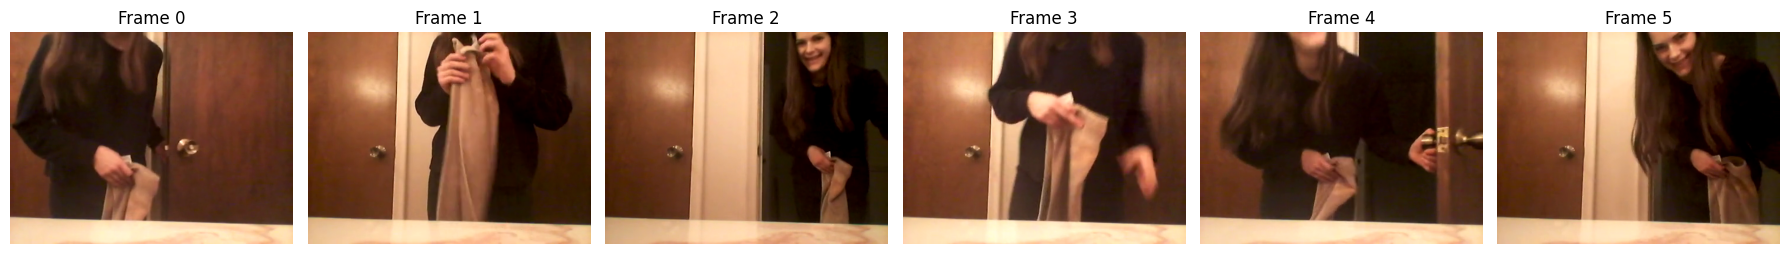

In [ ]:
qa_viz.vis_video_frames(
    {"question_id": idx, **gt_df.loc[idx].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR
)


In [63]:
if DISPLAY_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


	Video Seg:  4.3s - 10.3s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## Loading the QA on the statically generated STSG

## Correlation

In [64]:
pred_vqa_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
pred_sgg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    pred_vqa_df['pred_text1'],
    how='inner'
).join(
    pred_sgg_df['pred_text2'],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all


,question,video_id,start,end,text,question_program,choices,situations,pred_text1,pred_text2
id,,,,,,,,,,
Feasibility_T5_102,Which object is the person able to throw after...,ATV2F,0.0,4.000,the clothes.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The bag.', 'choic...","{'000031': {'rel_pairs': [['o000', 'o019'], ['...",the bag.,none of the others.
Feasibility_T2_860,What else is the person able to do with the wi...,9J166,9.9,17.500,close the window.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Lie on the window...","{'000321': {'rel_pairs': [['o000', 'o017'], ['...",hold the window.,none of the others.
Feasibility_T2_556,What else is the person able to do with the cl...,ANA5N,4.3,10.300,open the closet/cabinet.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Tidy up the close...","{'000390': {'rel_pairs': [['o000', 'o011'], ['...",open the closet/cabinet.,none of the others.
Prediction_T1_2539,What will the person do next?,Z6HEA,0.0,10.875,sit on the floor.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Sit on the floor....","{'000021': {'rel_pairs': [['o000', 'o027'], ['...",open the bag.,none of the others.
Prediction_T4_1253,Which object would the person throw next after...,FRLW2,3.4,27.275,the shoe.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The pillow.', 'ch...","{'000811': {'rel_pairs': [['o000', 'o022'], ['...",none of the above.,the pillow.
...,...,...,...,...,...,...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,F9YMU,11.9,16.500,the paper/notebook.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The paper/noteboo...","{'000213': {'rel_pairs': [['o000', 'o006'], ['...",the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,1333C,8.0,13.100,the dish.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The towel.', 'cho...","{'000241': {'rel_pairs': [['o000', 'o027'], ['...",none of the above.,the black_object.
Interaction_T2_1847,What did the person do with the paper/notebook?,1TIAK,8.3,12.500,took.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Put down.', 'choi...","{'000210': {'rel_pairs': [['o000', 'o011']], '...",took.,took.


In [65]:
eval_df_all['pred_text2'].str.startswith("none",).sum()


np.int64(673)

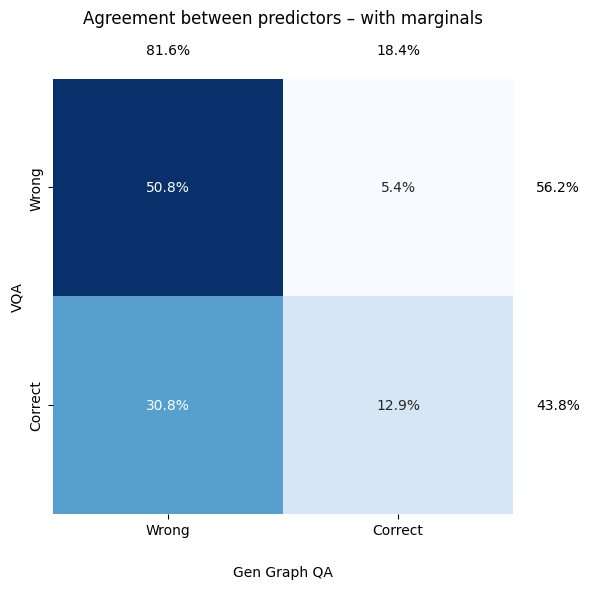

In [66]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gen Graph QA', labelpad=20)
ax.set_ylabel('VQA')
ax.set_title('Agreement between predictors – with marginals', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


The graph above tell us the following insights:
- In ~20% the samples the VQA is able to guess the right response where the Graph based QA mistakes
- On the other hand, there's a significant 12% where the Graph based QA is correct and the VQA is wrong


In [67]:
vqa_correct_gg_wrong = pred_vqa_correct & ~pred_gg_correct
mask = vqa_correct_gg_wrong.astype(bool)


In [68]:
indices = eval_df_all[mask].index
test1 = indices[0]


In [69]:
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_sgg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'SGG-QA'])



┌─ Sample: Feasibility_T2_556 ──────────────────────────────────────────────────────────────
│
│ Question:
│    What else is the person able to do with the closet/cabinet?
│ Alternatives:
│    0. Tidy up the closet/cabinet.
│    1. Open the closet/cabinet.
│    2. Close the closet/cabinet.
│    3. Wash the closet/cabinet.
│
│ Ground Truth:
│    Open the closet/cabinet.
│
|
│ Model Predictions - VQA:
│    Prediction:  Open the closet/cabinet. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and respond to the question.
│        
│        **1. Question Interpretation:** The question asks what the person is doing with the closet/cabinet, implying an action related to opening or manipulating it.
│        
│        **2. Video Analysis:**
│        *   **Frame Sequence:** The video shows a woman in a black dress repeatedly holding and manipulating a light-colored, draped fabric (likely a scarf or shawl) in front of a closed door. She’s adjusting the fabric, pulling it, and se

In [70]:
test1 = indices[1]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_sgg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'SGG-QA'])



┌─ Sample: Feasibility_T5_1851 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object is the person able to close after taking the cup/glass/bottle?
│ Alternatives:
│    0. The door.
│    1. The book.
│    2. The laptop.
│    3. The closet/cabinet.
│
│ Ground Truth:
│    The laptop.
│
|
│ Model Predictions - VQA:
│    Prediction:  the laptop. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and respond to the question.
│        
│        **1. Question Interpretation:** The question asks which object the person is able to close after taking a cup/glass/bottle. This implies a physical action – closing something.
│        
│        **2. Video Analysis:**
│        
│        *   **Person:** The person is seated in a wheelchair, holding a cup/glass/bottle and appears to be drinking from it.
│        *   **Objects in the Scene:** The scene includes a table, a laptop, a book, a door (partially visible), and a closet/cabinet.
│        *   

In [71]:
test1 = indices[2]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_sgg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'SGG-QA'])




┌─ Sample: Prediction_T2_450 ───────────────────────────────────────────────────────────────
│
│ Question:
│    What will the person do next with the clothes?
│ Alternatives:
│    0. Put down.
│    1. Take.
│    2. Throw.
│    3. Sit at.
│
│ Ground Truth:
│    Take.
│
|
│ Model Predictions - VQA:
│    Prediction:  Take. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks what the person will *do next* with the clothes. It’s essentially asking about the next action observed in the video.
│        
│        **2. Video Analysis:**
│        
│        *   **Initial Observation:** The video shows a person (likely a woman) kneeling and bending over a laundry sink. She is holding a small, white, plastic object (possibly a toy or a small cleaning tool) in her hand. She appears to be examining something on the floor near the sink.
│        *   **Subsequent Actions:** The person is now care

## Inspecting the performance of VQA on previously inspected samples


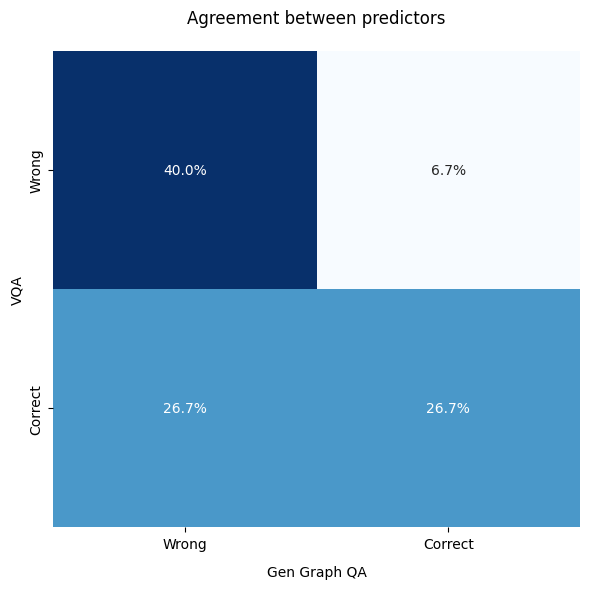

In [72]:
display_eval = eval_df_all.loc[prev_analyzed]

pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_sgg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_sgg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gen Graph QA', labelpad=10)
ax.set_ylabel('VQA')
ax.set_title('Agreement between predictors', pad=20)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


In [73]:
vqa_correct_sgg_wrong = pred_vqa_correct & ~pred_sgg_correct
mask = vqa_correct_sgg_wrong.astype(bool)
indices = display_eval[mask].index

